# Module 10 — PyTorch Fundamentals

*Everything you built by hand in Module 09, handed to power tools.*

In Module 09 you ran PCR by hand: you made every weight matrix with `np.random`, derived every gradient with the chain rule on paper, and wrote the downhill update yourself. **PyTorch** is the thermocycler — the same reactions, automated. Every line of this notebook maps back to something you already built by hand.

We warm up on the same **two-moons** toy data as Module 09, then graduate to real patients: the **Cleveland heart-disease study**. In the late 1980s, cardiologist Robert Detrano and colleagues at the Cleveland Clinic recorded 13 clinical measurements — age, blood pressure, cholesterol, ECG readings, a thallium stress test — for 303 patients, along with the answer from angiography (threading a catheter into the coronary arteries, the gold-standard test): does this patient have heart disease? You met these patients in Module 06 with logistic regression and random forests. Today a neural network gets its turn — and we'll check, honestly, whether it earns its keep on only 303 people.

Run each cell in order; predict before you run. Every non-obvious line has a `#` comment explaining it.

In [1]:
import numpy as np                  # arrays (Module 01)
import pandas as pd                 # tables (Module 02)
import matplotlib.pyplot as plt     # plots
import seaborn as sns               # nicer plots
import torch                        # PyTorch -- the star of this module
from torch import nn                # 'nn' = PyTorch's neural-network building blocks

sns.set_theme(style="whitegrid", palette="colorblind")

# Two fixed colors we reuse in every plot: class 0 is blue, class 1 is orange.
palette = sns.color_palette("colorblind")
BLUE = palette[0]
ORANGE = palette[1]

np.random.seed(42)        # same NumPy random numbers on every run
torch.manual_seed(42)     # same PyTorch random numbers on every run

print("PyTorch version:", torch.__version__)

PyTorch version: 2.13.0


## 1. Tensors — NumPy arrays that remember their math

PyTorch's basic object is the **tensor**. For now, think of it as a NumPy array with two superpowers we'll meet in a moment: it can *remember the operations done to it* (for automatic gradients), and it can live on a GPU. Everything you know from Module 01 — shapes, dtypes, element-wise math, `@` — carries straight over.

In [2]:
# torch.tensor() builds a tensor from a plain Python list, just like np.array().
temperatures = torch.tensor([36.6, 37.1, 38.2, 36.9])   # body temperatures, degrees C

print(temperatures)
print("shape:", temperatures.shape)
print("dtype:", temperatures.dtype)

# Math works exactly like NumPy: element-wise, no loop needed.
print("in Fahrenheit:", temperatures * 9 / 5 + 32)
print("mean:", temperatures.mean())

tensor([36.6000, 37.1000, 38.2000, 36.9000])
shape: torch.Size([4])
dtype: torch.float32
in Fahrenheit: tensor([ 97.8800,  98.7800, 100.7600,  98.4200])
mean: tensor(37.2000)


In [3]:
# Tensors and NumPy arrays convert back and forth freely.
np_array = np.array([1.0, 2.0, 3.0])          # a plain NumPy array

as_tensor = torch.from_numpy(np_array)        # torch.from_numpy = wrap a NumPy array as a tensor
back_again = as_tensor.numpy()                # .numpy() = see the tensor as a NumPy array again

print("NumPy:      ", np_array)
print("as tensor:  ", as_tensor)
print("back again: ", back_again)

NumPy:       [1. 2. 3.]
as tensor:   tensor([1., 2., 3.], dtype=torch.float64)
back again:  [1. 2. 3.]


### The dtype gotcha (you WILL hit this one day)

NumPy's default decimal type is `float64` (64 bits per number). PyTorch's default is `float32` — half the memory, and plenty of precision for neural networks. The trap: `torch.from_numpy` *keeps* the NumPy dtype, so you get a `float64` tensor, and the first time you feed it to a network built of `float32` weights, PyTorch stops with:

```
RuntimeError: expected scalar type Float but found Double
```

("Float" is PyTorch-speak for float32, "Double" for float64.) The fix is one call — convert the NumPy array with `.astype(np.float32)` before wrapping it. We will do this every single time we hand NumPy data to PyTorch.

In [4]:
print("NumPy default dtype:  ", np_array.dtype)                 # float64
print("PyTorch default dtype:", temperatures.dtype)             # float32
print("from_numpy keeps it:  ", torch.from_numpy(np_array).dtype)

# The fix -- convert to float32 BEFORE wrapping. Memorize this pattern.
fixed = torch.from_numpy(np_array.astype(np.float32))
print("after astype(float32):", fixed.dtype)

NumPy default dtype:   float64
PyTorch default dtype: torch.float32
from_numpy keeps it:   torch.float64
after astype(float32): torch.float32


## 2. Autograd — the chain rule, automated

In Module 09, the hard part was **backpropagation**: deriving, by hand, how much the loss changes when each weight changes (the gradient), using the chain rule. PyTorch's **autograd** does that derivation for you.

The trick: mark a tensor with `requires_grad=True`, and PyTorch records every operation done to it — like a lab notebook that writes itself. Call `.backward()` on the final result, and PyTorch replays the notebook *backwards*, multiplying local derivatives as it goes. That's the chain rule, executed by machine.

Let's verify it on an expression small enough to check by hand — and it's an old friend: `loss = (w − 3)²`, the exact 1-D bowl you walked down in Module 09's gradient-descent section. There you wrote the slope function yourself: derivative = `2 × (w − 3)`, so at `w = 2` the slope is `2 × (2 − 3)` = **−2**. (The minus sign says: to make the loss smaller, *increase* w — makes sense, since the loss is smallest at w = 3.)

In [5]:
# requires_grad=True tells PyTorch: "track everything that happens to this tensor".
w = torch.tensor(2.0, requires_grad=True)

loss = (w - 3) ** 2          # PyTorch computes 1.0 AND records: subtract, then square
print("loss:", loss.item())  # .item() = pull the single Python number out of a tensor

loss.backward()              # replay the recording backwards: the chain rule, automated

print("PyTorch says   w.grad =", w.grad.item())
print("by hand      2*(w - 3) =", 2 * (2.0 - 3.0))

loss: 1.0
PyTorch says   w.grad = -2.0
by hand      2*(w - 3) = -2.0


Identical. And this scales: a network with millions of weights is just a much longer recording, and `loss.backward()` fills in a `.grad` for *every* weight in one call. The chain-rule homework of Module 09 is now one line — but you know exactly what that line is doing.

## 3. The network as a parts list

Time to rebuild Module 09's two-moons network. First, the same data: two interleaved crescents that no straight line can separate.

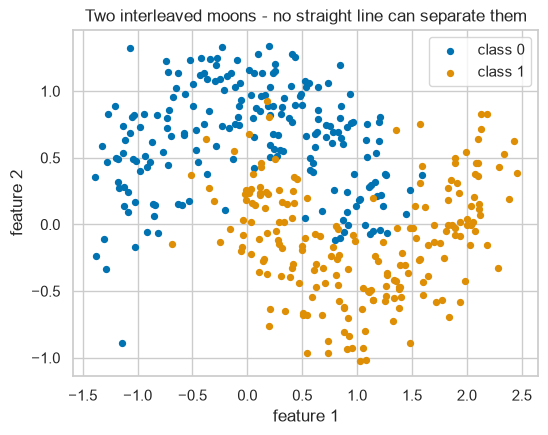

In [6]:
from sklearn.datasets import make_moons   # the same toy-data maker as Module 09

# 400 points in two interleaved crescents, with noise so they overlap a little.
X_moons, y_moons = make_moons(n_samples=400, noise=0.25, random_state=42)

fig, ax = plt.subplots(figsize=(6, 4.5))
class0 = y_moons == 0                     # boolean mask: True where the label is 0 (Module 01)
class1 = y_moons == 1
ax.scatter(X_moons[class0, 0], X_moons[class0, 1], color=BLUE, s=18, label="class 0")
ax.scatter(X_moons[class1, 0], X_moons[class1, 1], color=ORANGE, s=18, label="class 1")
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.set_title("Two interleaved moons - no straight line can separate them")
ax.legend()
plt.show()

In [7]:
# Hand the data to PyTorch -- note the float32 conversion from Section 1.
X_moons_t = torch.from_numpy(X_moons.astype(np.float32))

# The labels need two touches:
#   .astype(np.float32)  -- the loss function wants decimals, not integers
#   .reshape(-1, 1)      -- from a flat list of 400 into a 400x1 column,
#                           matching the network's output shape (-1 = "figure
#                           out this dimension for me", Module 01)
y_moons_t = torch.from_numpy(y_moons.astype(np.float32)).reshape(-1, 1)

print("X:", X_moons_t.shape, X_moons_t.dtype)
print("y:", y_moons_t.shape, y_moons_t.dtype)

X: torch.Size([400, 2]) torch.float32
y: torch.Size([400, 1]) torch.float32


Now the network itself. In Module 09 you built it from four arrays — a weight matrix and bias vector for each layer — plus an activation function. PyTorch packages each piece:

- **`nn.Linear(2, 8)`** — a layer that takes 2 inputs and produces 8 outputs. Inside it stores exactly what you made with `rng.normal`: a weight matrix and a bias vector, already initialized with sensible random values.
- **`nn.ReLU()`** — an activation function, as a ready-made part. Module 09's committee bent its straight lines with tanh; today we use **ReLU** from Module 09's activation gallery ("silent below 0, pass-through above") — the modern default. Either one works; without *some* bend, remember, stacked linear layers collapse into one straight line.
- **`nn.Sequential(...)`** — a rack that bolts the parts together in order: data flows in the top and out the bottom.

Two inputs → 8 hidden neurons (the committee) → 1 output. Same anatomy as Module 09.

In [8]:
torch.manual_seed(42)   # re-seed just before building, so the random starting
                        # weights are the same even if you re-run earlier cells

moons_model = nn.Sequential(
    nn.Linear(2, 8),    # layer 1: stores an 8x2 weight matrix W and a length-8 bias b
    nn.ReLU(),          # activation: the bend that lets the boundary curve
    nn.Linear(8, 1),    # layer 2: 8 hidden values -> 1 raw output score
)
print(moons_model)

# Count the learnable parameters -- every number the training loop will adjust.
total = 0
for p in moons_model.parameters():          # yields each W matrix and b vector in turn
    count = p.numel()                       # .numel() = number of elements in the tensor
    print(list(p.shape), "->", count, "numbers")
    total = total + count
print("total learnable parameters:", total)

Sequential(
  (0): Linear(in_features=2, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)
[8, 2] -> 16 numbers
[8] -> 8 numbers
[1, 8] -> 8 numbers
[1] -> 1 numbers
total learnable parameters: 33


**33 knobs — the exact count from Module 09.** These are the same `W1, b1, W2, b2` you created with `rng.normal` and `np.zeros`, just pre-made. (One cosmetic difference: PyTorch stores layer 1's weights as an 8×2 matrix where Module 09's `W1` was 2×8 — the same 16 numbers, transposed.) And `requires_grad=True` is already set on all of them, so autograd is watching every one.

## 4. The training loop liturgy

Two more parts, then the ritual:

- **Loss function.** `nn.BCEWithLogitsLoss()` is **binary cross-entropy**, the standard loss for yes/no questions (Module 06's logistic regression secretly minimizes the same thing). "WithLogits" means it takes the network's raw score (a **logit**) and applies the sigmoid squash internally — doing the two together is numerically safer.
- **Optimizer.** `torch.optim.SGD` is exactly Module 09's update rule, `weight = weight − learning_rate × gradient`, applied to every parameter for you. (SGD = stochastic gradient descent.)

Then the five-line loop from the README figure — the liturgy. It never changes, from these 33 parameters to GPT:

In [9]:
loss_fn = nn.BCEWithLogitsLoss()      # binary cross-entropy (sigmoid included)

# The optimizer gets the list of parameters it's allowed to adjust, plus
# the learning rate (lr) -- Module 09's step size, same meaning here.
optimizer = torch.optim.SGD(moons_model.parameters(), lr=0.5)

moons_losses = []                     # we'll record the loss after every epoch

# 1500 epochs on all 400 points at once ("full batch") -- runs in about a second.
for epoch in range(1500):
    # ---- the liturgy: five lines, always in this order ----
    predictions = moons_model(X_moons_t)      # 1. FORWARD: push data through the net
    loss = loss_fn(predictions, y_moons_t)    # 2. LOSS: one number, how wrong are we?
    optimizer.zero_grad()                     # 3. ZERO: erase last cycle's gradients
    loss.backward()                           # 4. BACKWARD: autograd fills every .grad
    optimizer.step()                          # 5. STEP: nudge every weight downhill
    # -------------------------------------------------------
    moons_losses.append(loss.item())          # save the number for plotting

print("first loss:", moons_losses[0])
print("last loss: ", moons_losses[-1])        # [-1] = last element (Module 01)

first loss: 0.7185900211334229
last loss:  0.15110616385936737


Why `zero_grad()`? PyTorch *adds* new gradients onto whatever is already in `.grad` (useful in advanced tricks). If you forget to wipe the slate, cycle 2's gradients get stacked on cycle 1's and training goes haywire. Forgetting `zero_grad()` is the classic first PyTorch bug — like forgetting to empty the waste beaker between runs.

Now plot the recording — the loss curve, our ECG of training:

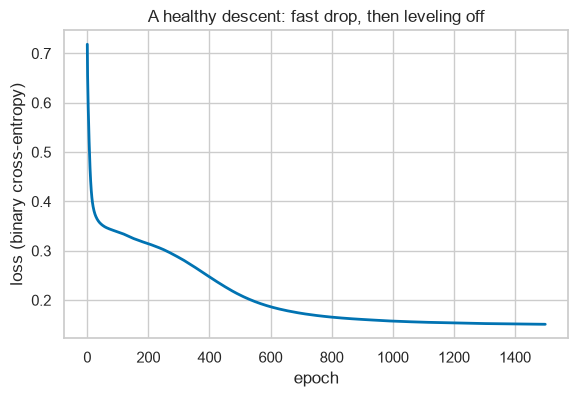

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(moons_losses, color=BLUE, linewidth=2)
ax.set_xlabel("epoch")
ax.set_ylabel("loss (binary cross-entropy)")
ax.set_title("A healthy descent: fast drop, then leveling off")
plt.show()

Compare with the loss-curve anatomy figure in the README: this is the healthy shape. Now the payoff — did PyTorch learn the same *curved* decision boundary that Module 09 earned by hand? We color every point of the plane by the network's predicted probability.

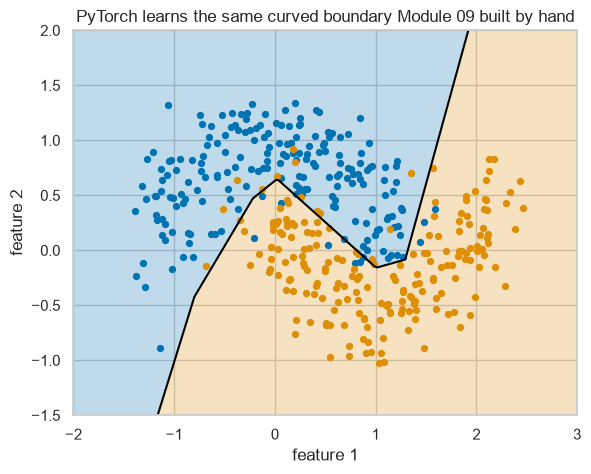

training accuracy: 0.935


In [11]:
# Build a fine grid of points covering the plot area (same trick as Module 09).
x_range = np.linspace(-2, 3, 200)             # 200 evenly spaced x values
y_range = np.linspace(-1.5, 2, 200)
xx, yy = np.meshgrid(x_range, y_range)        # np.meshgrid = all 200x200 grid crossings

# .ravel() flattens the grid to a list; column_stack pairs them into (x, y) rows.
grid = np.column_stack([xx.ravel(), yy.ravel()])
grid_t = torch.from_numpy(grid.astype(np.float32))

# torch.no_grad() = "just measuring, don't record for autograd" -- faster,
# and the right habit whenever you're evaluating rather than training.
with torch.no_grad():
    logits = moons_model(grid_t)              # raw scores for all 40,000 grid points
    probs = torch.sigmoid(logits)             # sigmoid squashes scores to 0..1 probabilities

zz = probs.numpy().reshape(xx.shape)          # back to a 200x200 sheet for plotting

fig, ax = plt.subplots(figsize=(6.5, 5))
# contourf fills regions: below 0.5 probability in blue, above in orange.
ax.contourf(xx, yy, zz, levels=[0, 0.5, 1], colors=[BLUE, ORANGE], alpha=0.25)
ax.contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=1.5)   # the boundary line
ax.scatter(X_moons[class0, 0], X_moons[class0, 1], color=BLUE, s=18)
ax.scatter(X_moons[class1, 0], X_moons[class1, 1], color=ORANGE, s=18)
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.set_title("PyTorch learns the same curved boundary Module 09 built by hand")
plt.show()

# Training accuracy: probability above 0.5 -> predict class 1.
with torch.no_grad():
    train_probs = torch.sigmoid(moons_model(X_moons_t))
predicted = (train_probs > 0.5).float()            # True/False -> 1.0/0.0
accuracy = (predicted == y_moons_t).float().mean() # fraction of matches (True counts as 1)
print(f"training accuracy: {accuracy.item():.3f}")   # ':.3f' = show 3 decimal places

Same S-shaped frontier snaking between the moons, ~93% accuracy — with the leftover errors sitting where the noisy crescents genuinely overlap. Module 09 took ~30 lines of NumPy and a page of chain rule; this took a parts list and the five-line liturgy.

## 5. DataLoader — feeding data in batches

So far we fed all 400 points at once. Real datasets don't fit: 70,000 images (Module 11), or millions of genomes, would blow past memory. And going one sample at a time wastes the fast matrix math from Module 01.

The compromise is the **mini-batch**: shuffle the data each epoch and serve it in plates of, say, 32 or 64 samples — process a 96-well plate at a time, not one tube and not the whole freezer. Each batch gives a slightly noisy estimate of the gradient, and that noise is *fine* — in practice the shuffling even helps the optimizer escape bad spots.

PyTorch has two small helpers:

- **`TensorDataset`** pairs up X and y row by row, so sample 17's features stay attached to sample 17's label.
- **`DataLoader`** shuffles and deals out the batches, one per lap of a `for` loop.

In [12]:
from torch.utils.data import TensorDataset, DataLoader

moons_dataset = TensorDataset(X_moons_t, y_moons_t)   # glue X and y together row-by-row
moons_loader = DataLoader(moons_dataset, batch_size=64, shuffle=True)

print("samples:", len(moons_dataset))
print("batches per epoch:", len(moons_loader))        # 400 samples / 64 per batch -> 7 (last one smaller)

# Peek at one batch. The loader hands out (X, y) pairs each lap of the loop.
for batch_X, batch_y in moons_loader:
    print("one batch of X:", batch_X.shape)
    print("one batch of y:", batch_y.shape)
    break   # 'break' = exit the loop immediately; we only wanted the first batch

samples: 400
batches per epoch: 7
one batch of X: torch.Size([64, 2])
one batch of y: torch.Size([64, 1])


To train with batches you nest the liturgy one level deeper: `for epoch in ...:` → `for batch_X, batch_y in loader:` → the five lines, on the batch. One pass through *all* the batches is still one epoch. We'll do exactly that on real patients right now.

## 6. A real problem: 303 hearts

Toy moons behind us. Load the Cleveland heart-disease patients from Module 06 — 303 people, 13 measurements each, and a `target` column: **1 = heart disease confirmed by angiography, 0 = healthy**.

In [13]:
from datasets import load_dataset      # the HuggingFace downloader (Module 01)

heart = load_dataset("buio/heart-disease", split="train").to_pandas()
print("shape:", heart.shape)
heart.head()

shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


One column needs care: `thal`, the **thallium stress test** — a radioactive tracer is injected and a scanner watches how well blood perfuses the heart muscle under exercise. Its values are text (`normal` / `fixed` defect / `reversible` defect), and networks eat only numbers. Also, this being real clinical data, a couple of rows contain data-entry typos — Module 06 hit the very same ones.

In [14]:
# value_counts shows every distinct value and how often it occurs (Module 02).
print(heart["thal"].value_counts())

thal
normal        168
reversible    115
fixed          18
1               1
2               1
Name: count, dtype: int64


In [15]:
# Two patients have '1' and '2' recorded -- typos, not real categories.
# We drop those rows, exactly as Module 06 did (you'd flag a mislabeled tube, too).
# .isin([...]) asks each row: "is your value one of these three?" -> True/False mask.
good_rows = heart["thal"].isin(["normal", "fixed", "reversible"])
heart = heart[good_rows].copy()      # keep the 301 clean rows; .copy() = own the new table

# get_dummies = one-hot encoding, same as Module 06: replace the one text column
# with one True/False column per category (thal_normal, thal_fixed, thal_reversible),
# so no fake ordering like normal=1, fixed=2 gets invented.
heart = pd.get_dummies(heart, columns=["thal"])

print("shape after cleaning:", heart.shape)
print(heart.columns.tolist())

shape after cleaning: (301, 16)
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'target', 'thal_fixed', 'thal_normal', 'thal_reversible']


Now the honest-scientist setup from Module 07: split *first*, then fit the scaler **on the training half only**. The test patients must stay unseen — if their means and spreads leak into the scaling, we've quietly shown the network the exam answers.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y = heart["target"]                      # 1 = heart disease, 0 = healthy
X = heart.drop(columns=["target"])       # every column EXCEPT the answer

# stratify=y keeps the same percentage of sick patients in both halves.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("training patients:", len(X_train), "| test patients:", len(X_test))

# StandardScaler rescales each column to mean 0, spread 1 -- otherwise
# cholesterol (~250) would drown out oldpeak (~1) just by being bigger.
scaler = StandardScaler()
# .astype(float) first: the thal_ columns are True/False, and the scaler wants numbers.
X_train_scaled = scaler.fit_transform(X_train.astype(float))   # LEARN mean/spread from train only
X_test_scaled = scaler.transform(X_test.astype(float))         # APPLY those same numbers to test
                                                               # (never fit on test -- Module 07!)

training patients: 225 | test patients: 76


In [17]:
torch.manual_seed(42)     # re-seed so this section gives the same numbers on its own

# The float32 conversion and the reshape, same as Section 3.
# (.to_numpy() turns the pandas y column into a plain array first.)
X_train_t = torch.from_numpy(X_train_scaled.astype(np.float32))
y_train_t = torch.from_numpy(y_train.to_numpy().astype(np.float32)).reshape(-1, 1)
X_test_t = torch.from_numpy(X_test_scaled.astype(np.float32))
y_test_t = torch.from_numpy(y_test.to_numpy().astype(np.float32)).reshape(-1, 1)

# Batches of 32 patients, reshuffled every epoch.
heart_dataset = TensorDataset(X_train_t, y_train_t)
heart_loader = DataLoader(heart_dataset, batch_size=32, shuffle=True)

n_features = X_train_t.shape[1]          # 15 columns after one-hot encoding
heart_model = nn.Sequential(
    nn.Linear(n_features, 16),           # 15 measurements -> 16 hidden neurons
    nn.ReLU(),
    nn.Linear(16, 1),                    # -> 1 raw score: evidence of disease
)
print(heart_model)

Sequential(
  (0): Linear(in_features=15, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)


Train — the same liturgy, now nested inside the batch loop. One addition: after each epoch we *measure* the loss on both halves (inside `torch.no_grad()`, since measuring isn't training). 200 epochs is deliberately too many — we **want** to watch overfitting happen.

In [18]:
loss_fn = nn.BCEWithLogitsLoss()
# Adam is a smarter cousin of SGD: it adapts each parameter's step size as it
# goes. It's the sensible default optimizer in modern practice.
optimizer = torch.optim.Adam(heart_model.parameters(), lr=0.01)

train_losses = []
test_losses = []

for epoch in range(200):                       # deliberately long, to expose overfitting
    for batch_X, batch_y in heart_loader:      # one lap = one plate of 32 patients
        predictions = heart_model(batch_X)     # 1. FORWARD
        loss = loss_fn(predictions, batch_y)   # 2. LOSS
        optimizer.zero_grad()                  # 3. ZERO
        loss.backward()                        # 4. BACKWARD
        optimizer.step()                       # 5. STEP

    # After each epoch: measure (not train!) on both halves.
    with torch.no_grad():
        train_loss = loss_fn(heart_model(X_train_t), y_train_t).item()
        test_loss = loss_fn(heart_model(X_test_t), y_test_t).item()
    train_losses.append(train_loss)
    test_losses.append(test_loss)

print(f"epoch   1: train {train_losses[0]:.3f} | test {test_losses[0]:.3f}")
print(f"epoch 200: train {train_losses[-1]:.3f} | test {test_losses[-1]:.3f}")

epoch   1: train 0.548 | test 0.567
epoch 200: train 0.018 | test 1.089


Look at that last line: the training loss ended near zero, the test loss got *worse*. Plot both curves and find the exact moment the network stopped learning cardiology and started memorizing its 225 training patients:

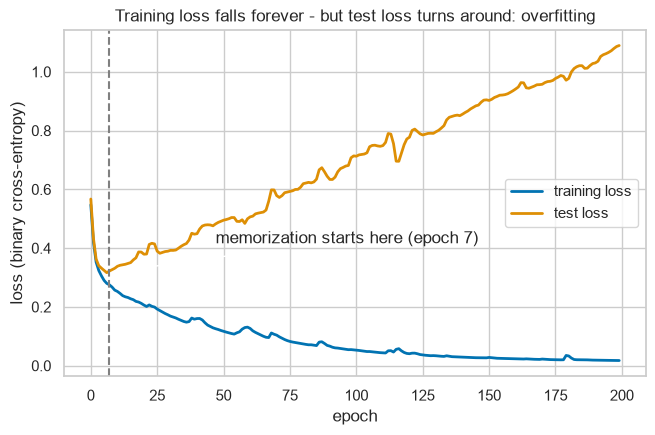

In [19]:
# np.argmin = the POSITION of the smallest value (not the value itself).
best_epoch = int(np.argmin(test_losses)) + 1     # +1 because epochs count from 1

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(train_losses, color=BLUE, linewidth=2, label="training loss")
ax.plot(test_losses, color=ORANGE, linewidth=2, label="test loss")
ax.axvline(best_epoch, color="gray", linestyle="--", linewidth=1.5)   # dashed marker line
ax.annotate(f"memorization starts here (epoch {best_epoch})",
            xy=(best_epoch, min(test_losses)),          # arrow points at the curve's low point
            xytext=(best_epoch + 40, min(test_losses) + 0.1),
            arrowprops=dict(arrowstyle="->"))
ax.set_xlabel("epoch")
ax.set_ylabel("loss (binary cross-entropy)")
ax.set_title("Training loss falls forever - but test loss turns around: overfitting")
ax.legend()
plt.show()

This is the third panel of the README's loss-curve anatomy, happening live. The two curves fall together at first (real learning — it transfers to unseen patients), then split: training loss keeps improving while test loss climbs. Past the dashed line, every extra epoch makes the network *worse* at medicine and better at reciting its training set — a student memorizing the answer key. The professional habit is to checkpoint the model at the low point of the test curve and stop there (called **early stopping**; you'll practice it in the exercises).

How good is the final model on the 76 patients it never saw?

In [20]:
with torch.no_grad():
    test_probs = torch.sigmoid(heart_model(X_test_t))    # raw scores -> probabilities

predicted_sick = (test_probs > 0.5).float()    # above 50% -> predict "disease" (1.0)
correct = (predicted_sick == y_test_t).float() # 1.0 where prediction matches truth
nn_accuracy = correct.mean().item()

print(f"neural network test accuracy: {nn_accuracy:.3f}")

neural network test accuracy: 0.842


## 7. The honest comparison

Around 84% on unseen patients — genuinely useful. But before celebrating, the honest-scientist move: give Module 06's random forest the *same* training patients and the *same* test patients, and compare.

In [21]:
from sklearn.ensemble import RandomForestClassifier

# 300 decision trees voting (Module 06). Forests don't care about scaling,
# so they get the raw, unscaled columns.
forest = RandomForestClassifier(n_estimators=300, random_state=42)
forest.fit(X_train, y_train)
forest_accuracy = forest.score(X_test, y_test)

# The lazy baseline: just predict "healthy" for everyone.
# y_test.mean() is the fraction of sick patients, so 1 minus it is this baseline's accuracy.
baseline = 1 - y_test.mean()

print(f"predict-healthy-for-everyone: {baseline:.3f}")
print(f"random forest:                {forest_accuracy:.3f}")
print(f"neural network:               {nn_accuracy:.3f}")

predict-healthy-for-everyone: 0.724
random forest:                0.842
neural network:               0.842


A tie. Thirty-three years of deep-learning progress, autograd, Adam — and the forest matches it while training in a fraction of a second with zero tuning.

That is the honest lesson, and it's worth stating plainly: **deep learning shines when there is LOTS of data.** With 303 patients and 15 tidy columns, a random forest has all the information there is to have; the network has too few examples to show off, and (as the loss curves showed) mostly finds new ways to memorize. This is why, for small tabular datasets — most spreadsheets a biologist meets — forests and their relatives remain the tool of choice.

So when *does* the network win? When the data is huge and raw — images, sequences, sound — where features like "cholesterol" don't come pre-extracted and the network must build its own. Module 11 hands ours 70,000 images of handwritten digits, and the story changes completely.

## 8. Devices: a quick tour of the Apple GPU

One more superpower tensors have over NumPy arrays: they can move to a **GPU** (graphics processing unit) — a chip with thousands of small cores that all do arithmetic at once, perfect for giant matrix multiplications. On this Mac, PyTorch reaches Apple's GPU through a backend called **MPS** (Metal Performance Shaders); on other machines you'd see NVIDIA's `"cuda"` instead. `.to("mps")` copies a tensor (or a whole model) onto it.

This lesson trained on the CPU on purpose: our models are tiny (33 and 273 parameters — no GPU needed), and CPU results are exactly reproducible run to run, while GPU arithmetic can differ in the last decimal places. But let's at least make the GPU flex once, on a matrix multiply big enough to matter.

In [22]:
import time                                # for the stopwatch

print("Apple GPU (MPS) available:", torch.backends.mps.is_available())

size = 6000
big = torch.randn(size, size)              # a 6000x6000 matrix of random numbers (36 million!)

# --- CPU timing ---
start = time.perf_counter()                # time.perf_counter = a precise stopwatch
result_cpu = big @ big                     # '@' = matrix multiplication (Module 01)
cpu_seconds = time.perf_counter() - start

if torch.backends.mps.is_available():
    # --- GPU timing ---
    big_mps = big.to("mps")                # copy the matrix onto the Apple GPU
    warmup = big_mps @ big_mps             # first GPU op pays a one-time setup cost --
                                           # run it once BEFORE timing, so we time only the math
    torch.mps.synchronize()                # GPU work runs in the background; synchronize()
                                           # means "wait until the GPU has truly finished"

    start = time.perf_counter()
    result_mps = big_mps @ big_mps
    torch.mps.synchronize()                # without this we'd stop the stopwatch while the
                                           # GPU was still working, and the time would be a lie
    mps_seconds = time.perf_counter() - start

    print(f"CPU:       {cpu_seconds:.4f} seconds")     # ':.4f' = 4 decimal places
    print(f"Apple GPU: {mps_seconds:.4f} seconds")
    print(f"speedup:   {cpu_seconds / mps_seconds:.1f}x")
else:
    print(f"CPU: {cpu_seconds:.4f} seconds (no MPS on this machine)")

Apple GPU (MPS) available: True


CPU:       0.2311 seconds
Apple GPU: 0.1458 seconds
speedup:   1.6x


Faster — though perhaps less dramatically than the hype promised. Apple's CPU has dedicated matrix hardware of its own, so on a single multiply it puts up a real fight. The GPU's advantage *compounds*: training a big network means thousands of these multiplies per second, on far bigger tensors, and there the gap widens into the days-versus-minutes territory that made GPUs famous. For the image networks of Module 11 and the capstone, the GPU starts to matter for real. When you want a whole model on the GPU, the recipe is: `model.to("mps")`, move each batch with `batch_X.to("mps")`, and everything else — the liturgy included — stays letter-for-letter the same.

---

### What you can do now

- Move data NumPy ↔ PyTorch (with the float32 conversion reflex).
- Get any gradient for free with `requires_grad` + `.backward()` — and explain what autograd recorded.
- Assemble a network from `nn.Linear` / `nn.ReLU` / `nn.Sequential` and count its parameters.
- Recite the liturgy: forward → loss → `zero_grad` → `backward` → `step`.
- Serve data in batches with `TensorDataset` + `DataLoader`.
- Read a train-vs-test loss plot and point at the epoch where overfitting begins.
- Say, with a straight face, when a random forest is the better tool.

Next, [exercises.md](exercises.md) — then Module 11, where the network finally gets enough data to earn its reputation.